In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings('ignore')

In [8]:
generator = load_model('cucumber_generator_exp2_one_class.h5')
discriminator = load_model('cucumber_discriminator_exp2_one_class.h5')

In [4]:
DATA_DIR = r"C:\Users\gabde\Downloads\archive\Cucumber Disease Recognition Dataset\Augmented Image\Augmented Image"
TARGET_CLASS = 'Fresh Cucumber'   # название класса, который будем генерировать
IMG_SIZE = 128                     # размер изображений
BATCH_SIZE = 32                     # размер батча
LATENT_DIM = 100                     # размерность шума
EPOCHS = 500                         # количество эпох
AUTOTUNE = tf.data.AUTOTUNE


In [6]:
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,                     # временно батч=1 для удобства фильтрации
    shuffle=False
)
class_names = full_ds.class_names
print("Все классы:", class_names)

Found 6400 files belonging to 8 classes.
Все классы: ['Anthracnose', 'Bacterial Wilt', 'Belly Rot', 'Downy Mildew', 'Fresh Cucumber', 'Fresh Leaf', 'Gummy Stem Blight', 'Pythium Fruit Rot']


In [7]:
class_dir = os.path.join(DATA_DIR, TARGET_CLASS)
if not os.path.isdir(class_dir):
    # Если папка не найдена, покажем доступные классы
    available = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
    raise ValueError(f"Класс '{TARGET_CLASS}' не найден. Доступные классы: {available}")

print(f"Загружаем изображения из: {class_dir}")

Загружаем изображения из: C:\Users\gabde\Downloads\archive\Cucumber Disease Recognition Dataset\Augmented Image\Augmented Image\Fresh Cucumber


In [8]:
# Получаем список всех файлов изображений в этой папке
image_paths = tf.data.Dataset.list_files(str(class_dir + '/*'), shuffle=False)
# Перемешиваем
image_paths = image_paths.shuffle(buffer_size=1000, seed=123)

In [9]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    # Нормализация в диапазон [-1, 1]
    img = (img / 127.5) - 1.0
    return img


In [10]:
dataset = image_paths.map(load_image, num_parallel_calls=AUTOTUNE)

In [93]:
def augment(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.clip_by_value(image, -1., 1.)
    return image

In [11]:
total_images = len(list(os.listdir(class_dir)))
val_size = int(0.2 * total_images)
train_size = total_images - val_size
print(f"Всего изображений: {total_images}, тренировочных: {train_size}, валидационных: {val_size}")

Всего изображений: 800, тренировочных: 640, валидационных: 160


In [12]:
train_ds = dataset.take(train_size).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = dataset.skip(train_size).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [32]:
def build_generator(latent_dim):
    noise_input = layers.Input(shape=(latent_dim,), name='noise')

    # Проекция и reshaping
    x = layers.Dense(8 * 8 * 512, use_bias=False)(noise_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((8, 8, 512))(x)

    # Серия транспонированных свёрток (upsampling до 128x128)
    x = layers.Conv2DTranspose(256, (5,5), strides=(2,2), padding='same', use_bias=False)(x)  # 16x16
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(128, (5,5), strides=(2,2), padding='same', use_bias=False)(x)  # 32x32
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False)(x)   # 64x64
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(32, (5,5), strides=(2,2), padding='same', use_bias=False)(x)   # 128x128
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Выходной слой: 3 канала, tanh
    output = layers.Conv2DTranspose(3, (5,5), strides=(1,1), padding='same',
                                    use_bias=False, activation='tanh')(x)

    model = tf.keras.Model(noise_input, output, name='Generator')
    return model


In [33]:
def build_discriminator(img_size):
    image_input = layers.Input(shape=(img_size, img_size, 3), name='image')

    # Свёрточные слои
    x = layers.Conv2D(64, (5,5), strides=(2,2), padding='same')(image_input)   # 64x64
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (5,5), strides=(2,2), padding='same')(x)            # 32x32
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, (5,5), strides=(2,2), padding='same')(x)            # 16x16
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(512, (5,5), strides=(2,2), padding='same')(x)            # 8x8
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    output = layers.Dense(1)(x)  # логит

    model = tf.keras.Model(image_input, output, name='Discriminator')
    return model


In [34]:
generator = build_generator(LATENT_DIM)
discriminator = build_discriminator(IMG_SIZE)

# Печать архитектур (опционально)
generator.summary()
discriminator.summary()


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ noise (InputLayer)                   │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32768)               │       3,276,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32768)               │         131,072 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_9 (LeakyReLU)            │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_5 (Conv2DTranspose) │ (None, 16, 16, 256)         │       3,276,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_10 (LeakyReLU)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_6 (Conv2DTranspose) │ (None, 32, 32, 128)         │         819,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_11 (LeakyReLU)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_7 (Conv2DTranspose) │ (None, 64, 64, 64)          │         204,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_12 (LeakyReLU)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_8 (Conv2DTranspose) │ (None, 128, 128, 32)        │          51,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_13 (LeakyReLU)           │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_9 (Conv2DTranspose) │ (None, 128, 128, 3)         │           2,400 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,764,192 (29.62 MB)

 Trainable params: 7,697,696 (29.36 MB)

 Non-trainable params: 66,496 (259.75 KB)

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                   │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 64)          │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_14 (LeakyReLU)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 128)         │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_15 (LeakyReLU)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 16, 16, 256)         │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_16 (LeakyReLU)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 8, 8, 512)           │       3,277,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_17 (LeakyReLU)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │          32,769 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,339,329 (16.55 MB)

 Trainable params: 4,339,329 (16.55 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Оптимизаторы
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

In [113]:
# 2й этап
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = tf.reduce_mean((real_output - 1.0) ** 2)
    fake_loss = tf.reduce_mean(fake_output ** 2)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return tf.reduce_mean((fake_output - 1.0) ** 2)

gen_lr = tf.keras.optimizers.schedules.ExponentialDecay(0.0003, decay_steps=10000, decay_rate=0.96)
disc_lr = tf.keras.optimizers.schedules.ExponentialDecay(0.00015, decay_steps=10000, decay_rate=0.96)

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=gen_lr, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=disc_lr, beta_1=0.5)

In [94]:
@tf.function
def train_step(images):
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Генерация фейковых изображений
        generated_images = generator(noise, training=True)

        # Оценка дискриминатором
        augmented_real = augment(images)
        real_output = discriminator(augmented_real, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Потери
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Градиенты
    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Применение оптимизаторов
    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss


In [15]:
def generate_and_save_images(epoch, generator, latent_dim, class_name):
    """Генерирует и сохраняет сетку изображений для одного класса."""
    num_examples = 8
    noise = tf.random.normal([num_examples, latent_dim])
    generated = generator(noise, training=False)

    fig, axes = plt.subplots(1, num_examples, figsize=(20, 4))
    for i in range(num_examples):
        img = (generated[i] + 1) / 2.0  # из [-1,1] в [0,1]
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(class_name)
    plt.savefig(f'generated_exp2_epoch_{epoch+1}.png')
    plt.show()


In [ ]:
for epoch in range(EPOCHS):
    total_gen_loss = 0
    total_disc_loss = 0
    num_batches = 0

    for image_batch in train_ds:  # меток нет, только изображения
        gen_loss, disc_loss = train_step(image_batch)
        total_gen_loss += gen_loss
        total_disc_loss += disc_loss
        num_batches += 1

    # Средние потери за эпоху
    avg_gen_loss = total_gen_loss / num_batches
    avg_disc_loss = total_disc_loss / num_batches

    print(f"Эпоха {epoch+1}/{EPOCHS}, Gen Loss: {avg_gen_loss:.4f}, Disc Loss: {avg_disc_loss:.4f}")

    # Каждые 10 эпох сохраняем примеры
    if (epoch + 1) % 5 == 0:
        generate_and_save_images(epoch, generator, LATENT_DIM, TARGET_CLASS)

In [53]:
generator.save('cucumber_generator_exp2_one_class.h5')
discriminator.save('cucumber_discriminator_exp2_one_class.h5')
print("Модели сохранены.")

Модели сохранены.


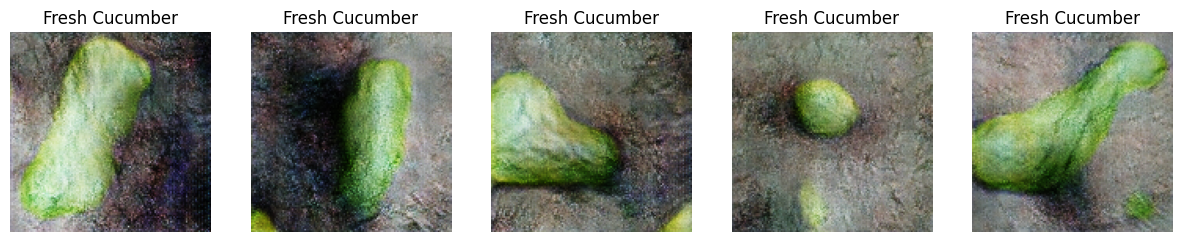

In [59]:
num_images = 5
noise = tf.random.normal([num_images, LATENT_DIM])
generated_images = generator(noise, training=False)
generated_images = (generated_images + 1) / 2.0  # в диапазон [0,1]

fig, axes = plt.subplots(1, num_images, figsize=(15, 4))
for i in range(num_images):
    axes[i].imshow(generated_images[i])
    axes[i].axis('off')
    axes[i].set_title(TARGET_CLASS)
plt.show()